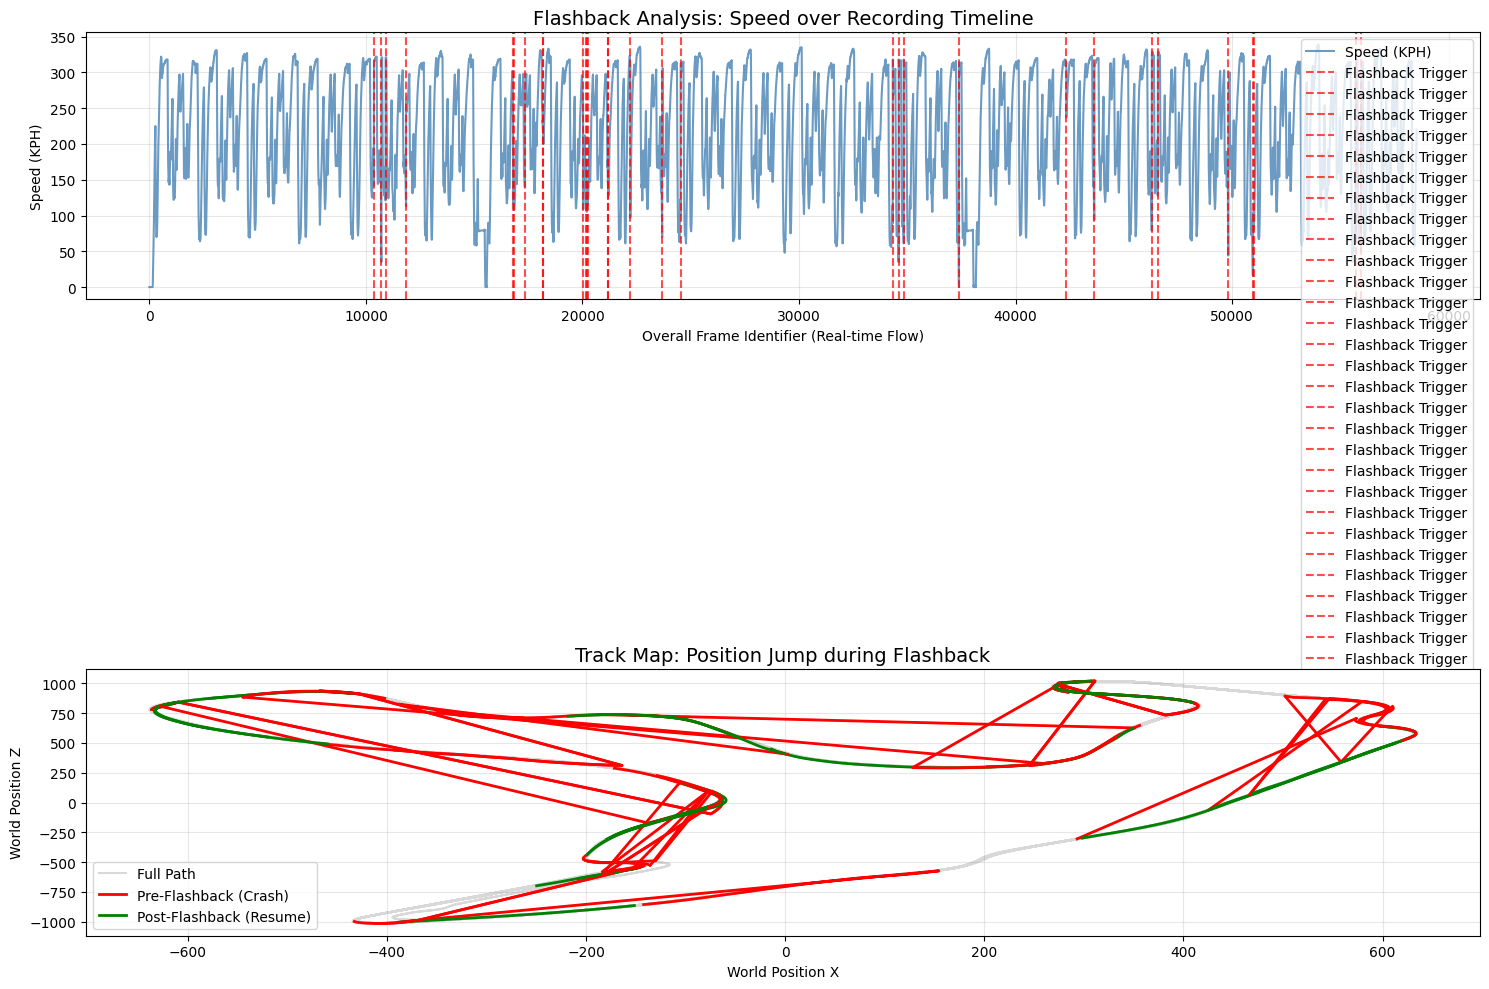

In [4]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import os

def load_f1_jsonl(filename):
    """JSONL 파일을 읽어 리스트로 변환"""
    data = []
    if not os.path.exists(filename):
        print(f"⚠️ 파일을 찾을 수 없습니다: {filename}")
        return None
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

def visualize_flashback():
    # 1. 데이터 로드
    motion_data = load_f1_jsonl(r'D:\code\work_space\record_motion.jsonl')
    telemetry_data = load_f1_jsonl(r'D:\code\work_space\record_telemetry.jsonl')
    event_data = load_f1_jsonl(r'D:\code\work_space\record_event.jsonl')

    if not motion_data or not telemetry_data:
        return

    # 2. 주행 데이터 추출 (플레이어 차량 기준)
    motion_list = []
    for d in motion_data:
        p_idx = d['m_header']['m_playerCarIndex']
        motion_list.append({
            'overall_frame': d['m_header']['m_overallFrameIdentifier'],
            'frame_id': d['m_header']['m_frameIdentifier'],
            'x': d['m_carMotionData'][p_idx]['m_worldPositionX'],
            'z': d['m_carMotionData'][p_idx]['m_worldPositionZ']
        })
    df_motion = pd.DataFrame(motion_list)

    tele_list = []
    for d in telemetry_data:
        p_idx = d['m_header']['m_playerCarIndex']
        tele_list.append({
            'overall_frame': d['m_header']['m_overallFrameIdentifier'],
            'speed': d['m_carTelemetryData'][p_idx]['m_speed']
        })
    df_tele = pd.DataFrame(tele_list)

    # 3. 되감기 이벤트 추출
    fb_events = []
    if event_data:
        for d in event_data:
            if d.get('event_info', {}).get('event_code') == 'FLBK':
                fb_events.append(d['m_header']['m_overallFrameIdentifier'])

    # 4. 시각화
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

    # [그래프 1] 속도 변화 및 되감기 시점 (Timeline 분석)
    ax1.plot(df_tele['overall_frame'], df_tele['speed'], label='Speed (KPH)', color='steelblue', alpha=0.8)
    for fb in fb_events:
        ax1.axvline(x=fb, color='red', linestyle='--', alpha=0.7, label='Flashback Trigger')
    
    ax1.set_title('Flashback Analysis: Speed over Recording Timeline', fontsize=14)
    ax1.set_xlabel('Overall Frame Identifier (Real-time Flow)')
    ax1.set_ylabel('Speed (KPH)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # [그래프 2] 트랙 위 위치 변화 (Jump/Overlap 분석)
    # 되감기 시 좌표가 갑자기 튀는 구간을 점으로 표시
    ax2.plot(df_motion['x'], df_motion['z'], color='gray', alpha=0.3, label='Full Path')
    
    # 되감기 발생 시점 전후 50프레임씩 강조해서 표시
    for fb in fb_events:
        # 되감기 직전 (사고 구간)
        crash_segment = df_motion[(df_motion['overall_frame'] > fb - 100) & (df_motion['overall_frame'] <= fb)]
        ax2.plot(crash_segment['x'], crash_segment['z'], color='red', linewidth=2, label='Pre-Flashback (Crash)')
        
        # 되감기 직후 (다시 시작하는 구간)
        resume_segment = df_motion[(df_motion['overall_frame'] > fb) & (df_motion['overall_frame'] <= fb + 100)]
        ax2.plot(resume_segment['x'], resume_segment['z'], color='green', linewidth=2, label='Post-Flashback (Resume)')

    ax2.set_title('Track Map: Position Jump during Flashback', fontsize=14)
    ax2.set_xlabel('World Position X')
    ax2.set_ylabel('World Position Z')
    ax2.grid(True, alpha=0.3)
    # 범례 중복 제거
    handles, labels = ax2.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax2.legend(by_label.values(), by_label.keys())

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_flashback()

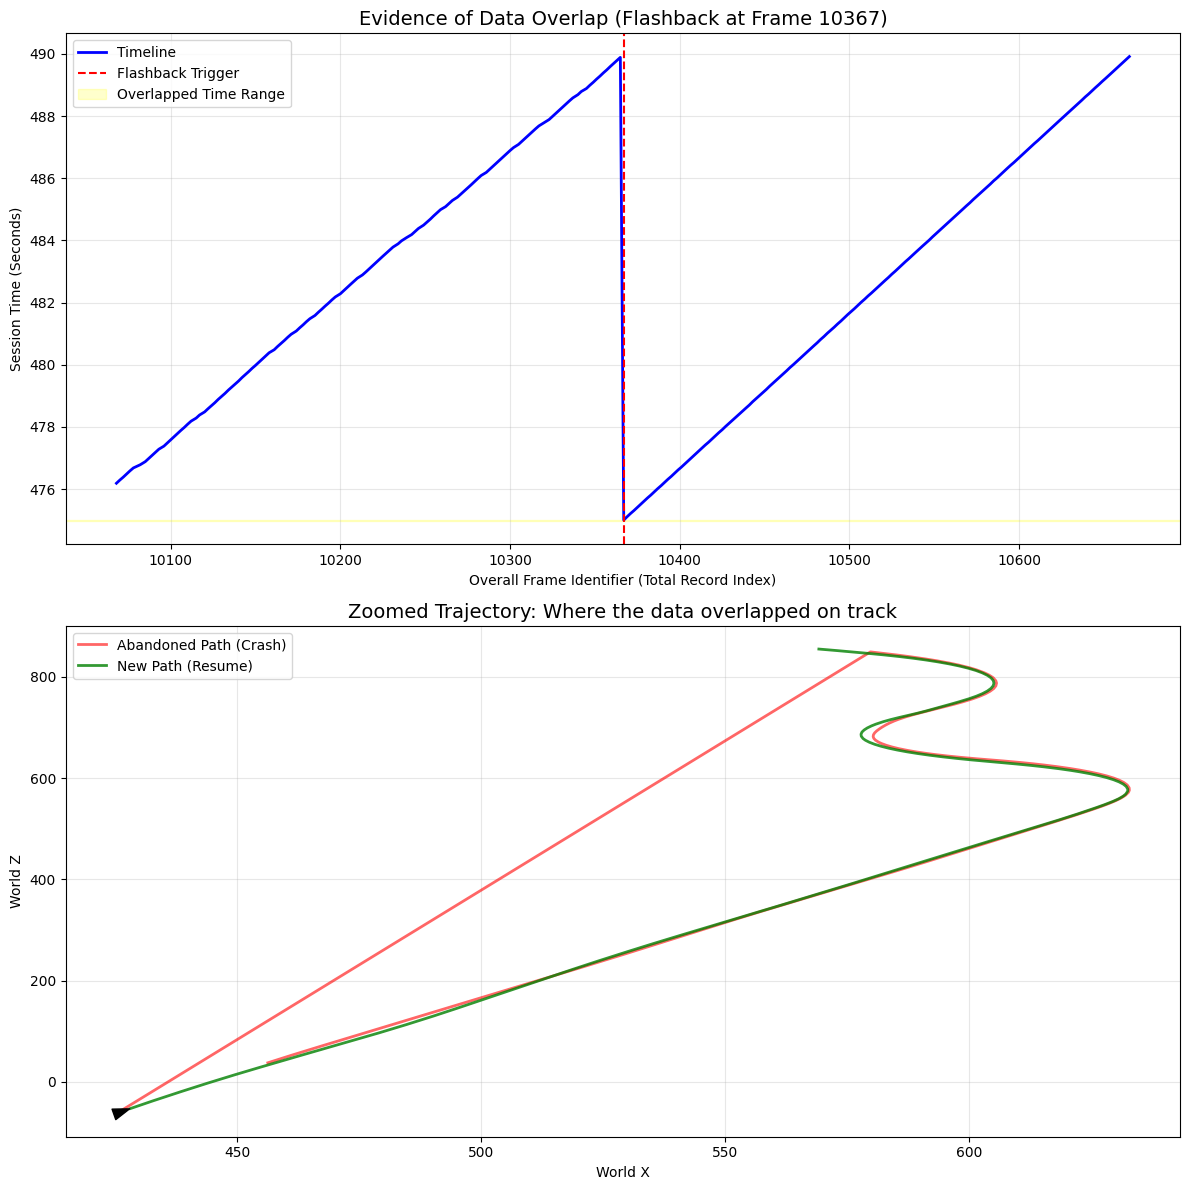

In [5]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

def load_data(filename):
    data = []
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            for line in f:
                data.append(json.loads(line))
        return data
    except FileNotFoundError:
        return None

# 1. 데이터 로드
motion_data = load_data(r'D:\code\work_space\record_motion.jsonl')
event_data = load_data(r'D:\code\work_space\record_event.jsonl')

if not motion_data or not event_data:
    print("데이터 파일이 부족합니다. (motion, event 파일 필요)")
else:
    # 2. 플레이어 데이터 추출 (Overall Frame과 Session Time 위주)
    records = []
    for d in motion_data:
        p_idx = d['m_header']['m_playerCarIndex']
        records.append({
            'overall_frame': d['m_header']['m_overallFrameIdentifier'],
            'session_time': d['m_header']['m_sessionTime'],
            'x': d['m_carMotionData'][p_idx]['m_worldPositionX'],
            'z': d['m_carMotionData'][p_idx]['m_worldPositionZ']
        })
    df = pd.DataFrame(records)

    # 3. 첫 번째 되감기(FLBK) 시점 찾기
    flashback_point = None
    for d in event_data:
        if d.get('event_info', {}).get('event_code') == 'FLBK':
            flashback_point = d['m_header']['m_overallFrameIdentifier']
            rewind_to_time = d['event_info']['details']['flashbackSessionTime']
            break

    if flashback_point is None:
        print("기록 중 되감기(Flashback) 이벤트가 발견되지 않았습니다.")
    else:
        # 4. 분석 구간 설정 (되감기 시점 전후 확대)
        # 되감기 발생 시점 근처의 데이터만 필터링
        margin = 300  # 약 5~10초 내외의 프레임 구간
        df_zoom = df[(df['overall_frame'] > flashback_point - margin) & 
                    (df['overall_frame'] < flashback_point + margin)].copy()

        # 시각화
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

        # [그래프 1] 중첩의 증거: Session Time vs Overall Frame
        # 정상 주행 시에는 우상향 직선이지만, 되감기 시 '계단식' 중첩 발생
        ax1.plot(df_zoom['overall_frame'], df_zoom['session_time'], color='blue', linewidth=2, label='Timeline')
        ax1.axvline(x=flashback_point, color='red', linestyle='--', label='Flashback Trigger')
        
        # 중첩 구간 강조 (동일한 Session Time이 발생하는 영역)
        overlap_time_min = rewind_to_time
        overlap_time_max = df[df['overall_frame'] == flashback_point]['session_time'].values[0]
        ax1.axhspan(overlap_time_min, overlap_time_max, color='yellow', alpha=0.2, label='Overlapped Time Range')

        ax1.set_title(f'Evidence of Data Overlap (Flashback at Frame {flashback_point})', fontsize=14)
        ax1.set_xlabel('Overall Frame Identifier (Total Record Index)')
        ax1.set_ylabel('Session Time (Seconds)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # [그래프 2] 물리적 중첩: X, Z 좌표 확대
        # 사고가 났던 경로(빨강)와 새로 달리는 경로(초록) 비교
        pre_fb = df_zoom[df_zoom['overall_frame'] <= flashback_point]
        post_fb = df_zoom[df_zoom['overall_frame'] > flashback_point]

        ax2.plot(pre_fb['x'], pre_fb['z'], color='red', alpha=0.6, linewidth=2, label='Abandoned Path (Crash)')
        ax2.plot(post_fb['x'], post_fb['z'], color='green', alpha=0.8, linewidth=2, label='New Path (Resume)')
        
        # 되감기로 인해 좌표가 튀는 지점에 화살표 표시
        start_jump = pre_fb.iloc[-1]
        end_jump = post_fb.iloc[0]
        ax2.annotate('', xy=(end_jump['x'], end_jump['z']), xytext=(start_jump['x'], start_jump['z']),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

        ax2.set_title('Zoomed Trajectory: Where the data overlapped on track', fontsize=14)
        ax2.set_xlabel('World X')
        ax2.set_ylabel('World Z')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


🔍 [되감기 감지] 프레임 10367:
   - 버튼 누른 시간: 475.001초
   - 되감기된 시간: 474.973초
   👉 총 0.028초 과거로 돌아갔습니다.

🔍 [되감기 감지] 프레임 10715:
   - 버튼 누른 시간: 479.803초
   - 되감기된 시간: 477.360초
   👉 총 2.443초 과거로 돌아갔습니다.

🔍 [되감기 감지] 프레임 10907:
   - 버튼 누른 시간: 479.803초
   - 되감기된 시간: 479.774초
   👉 총 0.029초 과거로 돌아갔습니다.

🔍 [되감기 감지] 프레임 11854:
   - 버튼 누른 시간: 512.103초
   - 되감기된 시간: 512.047초
   👉 총 0.056초 과거로 돌아갔습니다.

🔍 [되감기 감지] 프레임 16797:
   - 버튼 누른 시간: 739.149초
   - 되감기된 시간: 739.119초
   👉 총 0.030초 과거로 돌아갔습니다.

🔍 [되감기 감지] 프레임 16820:
   - 버튼 누른 시간: 739.149초
   - 되감기된 시간: 739.126초
   👉 총 0.023초 과거로 돌아갔습니다.

🔍 [되감기 감지] 프레임 17341:
   - 버튼 누른 시간: 750.135초
   - 되감기된 시간: 750.080초
   👉 총 0.055초 과거로 돌아갔습니다.

🔍 [되감기 감지] 프레임 18155:
   - 버튼 누른 시간: 775.783초
   - 되감기된 시간: 775.746초
   👉 총 0.037초 과거로 돌아갔습니다.

🔍 [되감기 감지] 프레임 18179:
   - 버튼 누른 시간: 775.783초
   - 되감기된 시간: 775.759초
   👉 총 0.024초 과거로 돌아갔습니다.

🔍 [되감기 감지] 프레임 20026:
   - 버튼 누른 시간: 852.332초
   - 되감기된 시간: 852.304초
   👉 총 0.028초 과거로 돌아갔습니다.

🔍 [되감기 감지] 프레임 20173:
   - 버튼 누른 시간: 852

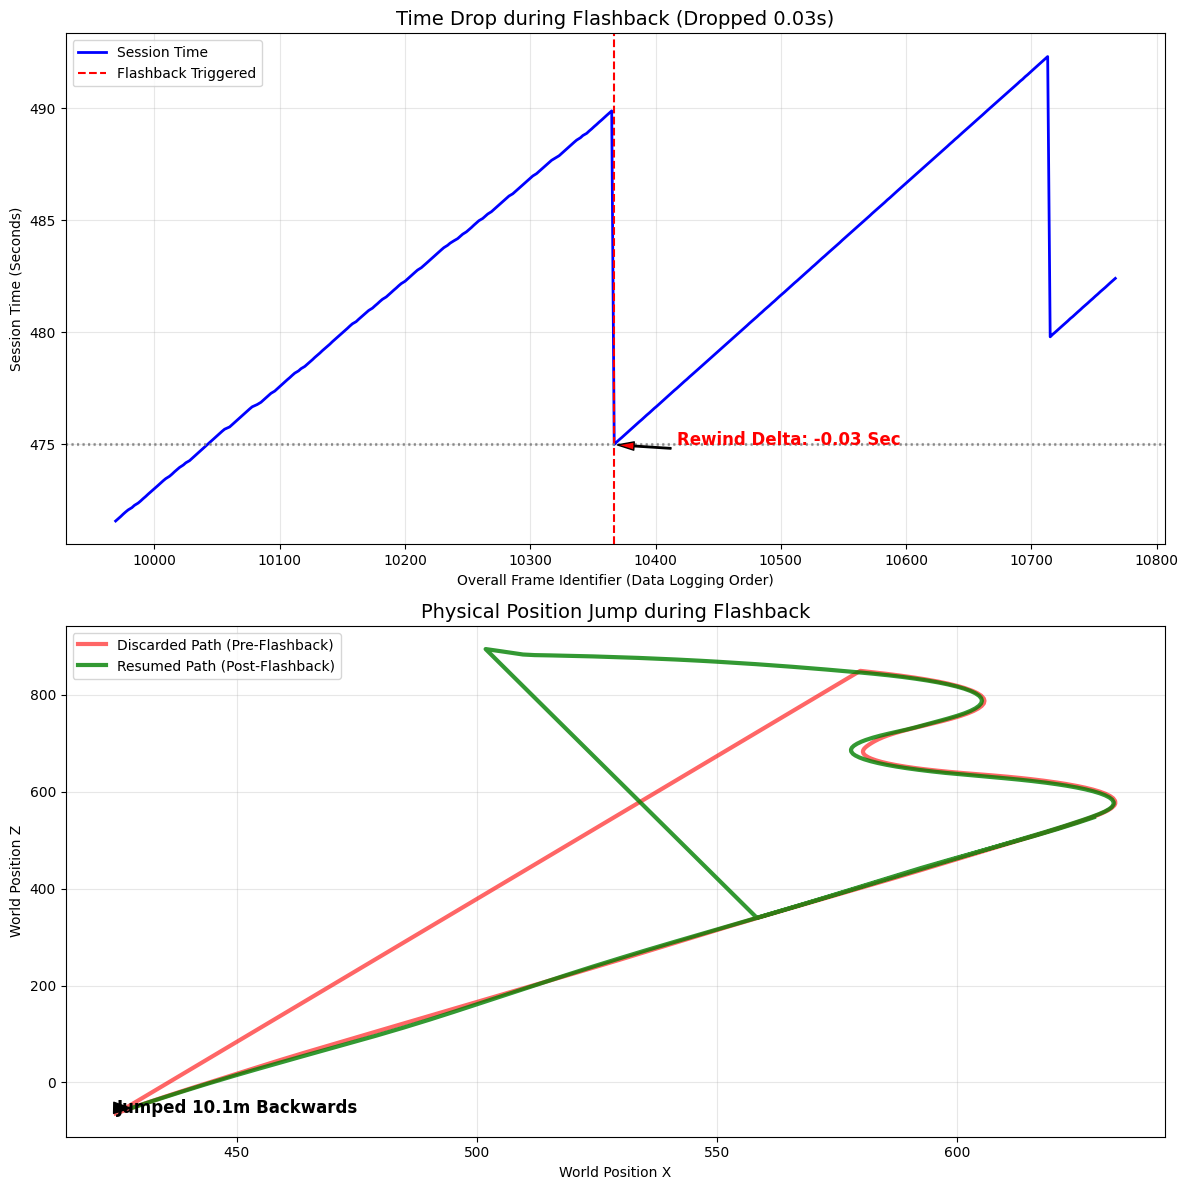

In [ ]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import numpy as np

def load_jsonl(filename):
    if not os.path.exists(filename):
        print(f"⚠️ {filename} 파일이 존재하지 않습니다.")
        return []
    with open(filename, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]

def analyze_and_visualize_flashback(motion_file, event_file):
    # 1. 데이터 로드
    motion_data = load_jsonl(motion_file)
    event_data = load_jsonl(event_file)

    if not motion_data or not event_data:
        return

    # 2. Motion 데이터프레임 생성 (위치 및 시간 정보)
    records = []
    for d in motion_data:
        header = d['m_header']
        p_idx = header['m_playerCarIndex']
        car_data = d['m_carMotionData'][p_idx]
        
        records.append({
            'overall_frame': header['m_overallFrameIdentifier'],
            'session_time': header['m_sessionTime'],
            'frame_id': header['m_frameIdentifier'],
            'x': car_data['m_worldPositionX'],
            'z': car_data['m_worldPositionZ']
        })
    df = pd.DataFrame(records)

    # 3. 되감기 이벤트(FLBK) 탐색 및 진짜 시간 계산
    flashbacks = []
    for e in event_data:
        if e.get('event_info', {}).get('event_code') == 'FLBK':
            trigger_frame = e['m_header']['m_overallFrameIdentifier']
            rewind_to_time = e['event_info']['details']['flashbackSessionTime']
            
            # [수정됨] 이벤트 프레임 이전에 기록된 데이터 중 가장 큰 session_time 찾기 (실제 사고 시점)
            pre_crash_data = df[df['overall_frame'] < trigger_frame]
            
            if not pre_crash_data.empty:
                crash_time = pre_crash_data['session_time'].max()
                rewind_delta = crash_time - rewind_to_time
                
                flashbacks.append({
                    'trigger_frame': trigger_frame,
                    'crash_time': crash_time,
                    'rewind_to_time': rewind_to_time,
                    'rewind_delta': rewind_delta
                })
                print(f"🔍 [되감기 감지] 전체 프레임 {trigger_frame}:")
                print(f"   - 진짜 사고 발생 시간: {crash_time:.3f}초")
                print(f"   - 되감기된 목표 시간: {rewind_to_time:.3f}초")
                print(f"   👉 트랙 위에서 총 {rewind_delta:.3f}초 만큼 과거로 돌아갔습니다.\n")

    if not flashbacks:
        print("기록 내에 되감기(FLBK) 이벤트가 없습니다.")
        return

    # 4. 시각화 (첫 번째 발생한 되감기 기준)
    fb = flashbacks[0]
    margin = 400  # 그래프에 보여줄 전후 프레임 수 (약 6~7초 분량)
    
    df_zoom = df[(df['overall_frame'] >= fb['trigger_frame'] - margin) & 
                 (df['overall_frame'] <= fb['trigger_frame'] + margin)]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

    # --- [그래프 1] 시간적 중첩 (Session Time Jump) ---
    ax1.plot(df_zoom['overall_frame'], df_zoom['session_time'], color='blue', linewidth=2, label='Session Time')
    
    ax1.axvline(x=fb['trigger_frame'], color='red', linestyle='--', label='Flashback Triggered')
    ax1.axhline(y=fb['crash_time'], color='gray', linestyle=':', alpha=0.7, label='Crash Time')
    ax1.axhline(y=fb['rewind_to_time'], color='gray', linestyle=':', alpha=0.7, label='Rewind To Time')
    
    # 시간차(Delta) 화살표 및 텍스트
    ax1.annotate(f"Rewind Delta: -{fb['rewind_delta']:.2f} Sec", 
                 xy=(fb['trigger_frame'], (fb['crash_time'] + fb['rewind_to_time'])/2),
                 xytext=(fb['trigger_frame'] + 50, (fb['crash_time'] + fb['rewind_to_time'])/2),
                 arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=6),
                 fontsize=12, color='red', fontweight='bold')

    ax1.set_title(f"Time Drop during Flashback (Dropped {fb['rewind_delta']:.2f}s)", fontsize=14)
    ax1.set_xlabel('Overall Frame Identifier (Data Logging Order)')
    ax1.set_ylabel('Session Time (Seconds)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- [그래프 2] 물리적 점프 (X, Z Trajectory) ---
    # 사고 전 궤적과 되감기 후 궤적 분리
    pre_fb = df_zoom[(df_zoom['overall_frame'] < fb['trigger_frame']) & (df_zoom['session_time'] >= fb['rewind_to_time'])]
    post_fb = df_zoom[(df_zoom['overall_frame'] > fb['trigger_frame'])]

    ax2.plot(pre_fb['x'], pre_fb['z'], color='red', alpha=0.6, linewidth=3, label='Discarded Path (Pre-Flashback)')
    ax2.plot(post_fb['x'], post_fb['z'], color='green', alpha=0.8, linewidth=3, label='Resumed Path (Post-Flashback)')
    
    # 두 지점 사이의 공간적 거리 계산
    if not pre_fb.empty and not post_fb.empty:
        # 사고 발생 직전의 가장 마지막 좌표
        crash_point = pre_fb.loc[pre_fb['session_time'].idxmax()]
        # 되감기 이후 새로 시작하는 좌표
        resume_point = post_fb.iloc[0]
        
        distance = np.sqrt((crash_point['x'] - resume_point['x'])**2 + (crash_point['z'] - resume_point['z'])**2)
        
        ax2.annotate(f"Jumped {distance:.1f}m Backwards", 
                     xy=(resume_point['x'], resume_point['z']), 
                     xytext=(crash_point['x'], crash_point['z']),
                     arrowprops=dict(facecolor='black', edgecolor='black', shrink=0.05, width=2, headwidth=8),
                     fontsize=12, fontweight='bold')

    ax2.set_title(f"Physical Position Jump during Flashback", fontsize=14)
    ax2.set_xlabel('World Position X')
    ax2.set_ylabel('World Position Z')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_and_visualize_flashback(r'D:\code\work_space\record_motion.jsonl', r'D:\code\work_space\record_event.jsonl')